In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


In [ ]:
# 2. Image Preprocessing Function
def preprocess_sheet(image_path, target_size=512):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        
    # Bilateral filter
    img = cv2.bilateralFilter(img, d=5, sigmaColor=30, sigmaSpace=10)
    
    # Resize with aspect ratio preserved, pad white
    h, w = img.shape
    scale = target_size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Create white canvas and place image in center
    canvas = np.full((target_size, target_size), 255, dtype=np.float32)
    y_off = (target_size - new_h) // 2
    x_off = (target_size - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = img
    
    return canvas / 255.0

In [ ]:
def augment_image(image):
    image = image[..., tf.newaxis]

    # Random scale 
    scale = tf.random.uniform([], 0.9, 1.1)
    tx = tf.random.uniform([], -0.05, 0.05) * 512.0
    ty = tf.random.uniform([], -0.05, 0.05) * 512.0

    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=image[tf.newaxis],
        transforms=tf.reshape(
            [scale, 0, tx, 0, scale, ty, 0, 0],
            [1, 8]
        ),
        output_shape=[512, 512],
        interpolation="BILINEAR",
        fill_mode="CONSTANT",
        fill_value=1.0
    )[0]

    # Brightness / contrast
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Gaussian noise
    noise = tf.random.normal(shape=tf.shape(image))
    image = tf.clip_by_value(image + noise, 0.0, 1.0)

    image_rgb = tf.image.grayscale_to_rgb(image)
    image_rgb = tf.keras.applications.resnet50.preprocess_input(image_rgb * 255.0)

    return image_rgb

In [ ]:
def make_dataset(df, indices, batch_size, augment=False):
    def gen():
        for idx in indices:
            row = df.iloc[idx]
            img = preprocess_sheet(row['image_path'])
            yield img, row['label']

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(512, 512), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )
    if augment:
        ds = ds.map(lambda img, lbl: (augment_image(img), tf.one_hot(lbl, 3)),
                    num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda img, lbl: (augment_image(img), tf.one_hot(lbl, 3)),
                    num_parallel_calls=tf.data.AUTOTUNE) 
    ds = ds.shuffle(len(indices)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def val_preprocess(image, label):
    image = image[..., tf.newaxis]
    image_rgb = tf.image.grayscale_to_rgb(image)
    image_rgb = tf.keras.applications.resnet50.preprocess_input(image_rgb * 255.0)
    return image_rgb, tf.one_hot(label, 3)

def make_val_dataset(df, indices, batch_size):
    ds = tf.data.Dataset.from_generator(
        lambda: ((preprocess_sheet(df.iloc[i]['image_path']), df.iloc[i]['label']) for i in indices),
        output_signature=(
            tf.TensorSpec(shape=(512, 512), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )
    ds = ds.map(val_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
def build_model():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(512, 512, 3))
    # Freeze all layers except the last two layers
    for layer in base.layers:
        if 'conv5' not in layer.name:
            layer.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
class_mapping = {
    'Normal': 0,
    'Neurosis': 1,
    'Intellectual_Disability': 2
}

df['label'] = df['Disease_Classification'].map(class_mapping)

df['image_path'] = 'Dataset/Raw_images/' + df['Case Number'].astype(str) + '.jpg'

df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

labels = df['label'].values

train_idx, val_idx = train_test_split(
    np.arange(len(df)), 
    test_size=0.2, 
    stratify=labels, 
    random_state=42
)

print(f"Training samples: {len(train_idx)}, Validation samples: {len(val_idx)}")

train_ds = make_dataset(df, train_idx, batch_size=8, augment=True)
val_ds = make_val_dataset(df, val_idx, batch_size=8)

model = build_model()

class_counts = np.bincount(labels[train_idx], minlength=3)
total = len(train_idx)
class_weight = {0: total / (3*class_counts[0]),
                1: total / (3*class_counts[1]),
                2: total / (3*class_counts[2])}


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight,
    verbose=1
)



Training samples: 70, Validation samples: 18
Epoch 1/50
      9/Unknown 56s 3s/step - accuracy: 0.6568 - loss: 2.6130

d:\Ai journey\Assignments\myenv2\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.8000 - loss: 1.5870 - val_accuracy: 0.9444 - val_loss: 0.2247 - learning_rate: 1.0000e-04
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.8857 - loss: 1.4026 - val_accuracy: 0.9444 - val_loss: 0.2350 - learning_rate: 1.0000e-04
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9000 - loss: 1.2461 - val_accuracy: 0.9444 - val_loss: 0.2011 - learning_rate: 1.0000e-04
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.8571 - loss: 1.0971 - val_accuracy: 0.9444 - val_loss: 0.2320 - learning_rate: 1.0000e-04
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7714 - loss: 0.9003 - val_accuracy: 0.9444 - val_loss: 0.3424 - learning_rate: 1.0000e-04
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.8286 - loss: 0.8761 - val_accuracy: 0.9444 - val_loss: 0.5936 - learning_rate: 1.0000e-04
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.9143 - loss: 0.5541 - val_accuracy: 0

ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

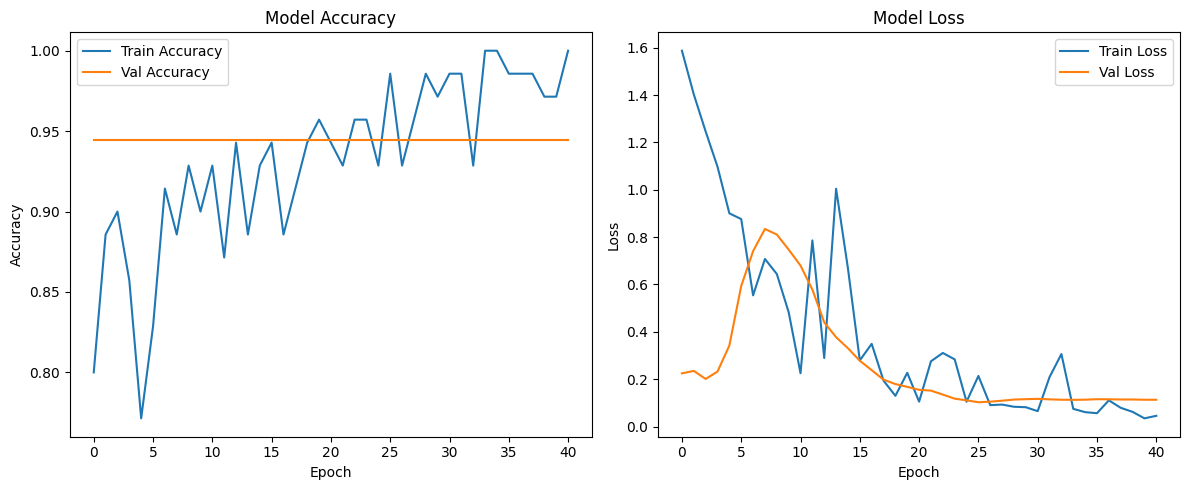

In [31]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

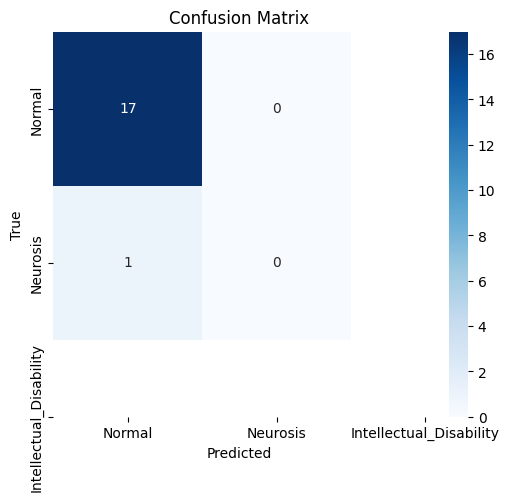

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_all,
            yticklabels=target_names_all)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()